In [31]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [32]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
dogsvscats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [33]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

## 1. Feature Extraction

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [35]:
# Pretrained Model

base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

In [36]:
# Freeze all layers ( Feature Extraction )

base_model.trainable = False

 # GlobalAveragePooling2D ব্যবহার করা হয় feature map-এর spatial dimensions (H×W) কে average করে একটি compact feature vector বানানোর জন্য, যাতে parameter কমে, overfitting কম হয় এবং training efficient হয়।

In [37]:
# Custom Head

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

In [38]:
model = Model(inputs=base_model.input, outputs=output)

In [39]:
# Compile

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [40]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
# Data Split

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/catsvsdogs/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (224, 224)
)

val_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/catsvsdogs/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (224, 224)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [42]:
# Train

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 116ms/step - accuracy: 0.9711 - loss: 0.0765 - val_accuracy: 0.9764 - val_loss: 0.0565
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9808 - loss: 0.0487 - val_accuracy: 0.9776 - val_loss: 0.0548
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - accuracy: 0.9853 - loss: 0.0390 - val_accuracy: 0.9782 - val_loss: 0.0568
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9880 - loss: 0.0323 - val_accuracy: 0.9786 - val_loss: 0.0634
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9905 - loss: 0.0261 - val_accuracy: 0.9784 - val_loss: 0.0660
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.9926 - loss: 0.0219 - val_accuracy: 0.9784 - val_loss: 0.0786
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.9947 - loss: 0.0152 - val_accuracy: 0.9784 - val_loss: 0.0788
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.9951 - loss: 0

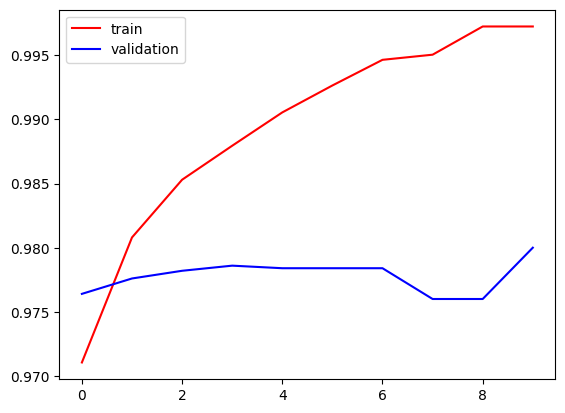

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

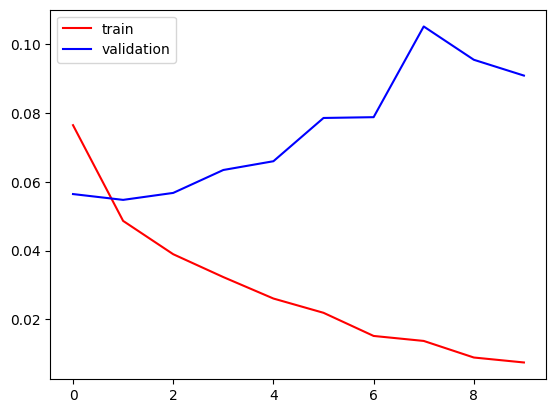

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

# 2. Fine Tuning

In [45]:
# Load pretrained ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [48]:
len(base_model.layers)

175

In [49]:
# Freeze first layers

for layer in base_model.layers[:140]:
  layer.trainable = False

In [50]:
# Unfreeze remaining layers

for layer in base_model.layers[140:]:
  layer.trainable = True

In [53]:
# Custom classifier

from tensorflow.keras.layers import Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

In [54]:
model = Model(inputs = base_model.input, outputs = output)

In [57]:
# Compile
from tensorflow.keras.optimizers import Adam


model.compile(
    optimizer=Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
    )

In [60]:
# Train

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 168ms/step - accuracy: 0.9273 - loss: 0.1822 - val_accuracy: 0.9780 - val_loss: 0.0549
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.9796 - loss: 0.0548 - val_accuracy: 0.9818 - val_loss: 0.0486
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.9887 - loss: 0.0310 - val_accuracy: 0.9824 - val_loss: 0.0490
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.9937 - loss: 0.0179 - val_accuracy: 0.9828 - val_loss: 0.0526
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9969 - loss: 0.0103 - val_accuracy: 0.9812 - val_loss: 0.0557
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 154ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.9832 - val_loss: 0.0613
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9836 - val_loss: 0.0659
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9990 - loss

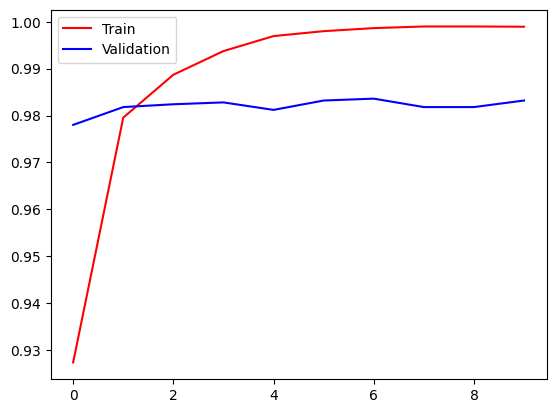

In [62]:
plt.plot(history.history['accuracy'], color = 'red', label = "Train")
plt.plot(history.history['val_accuracy'], color = 'blue', label = "Validation")
plt.legend()
plt.show()

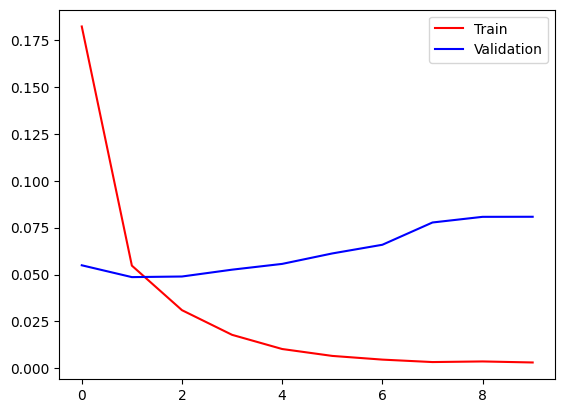

In [64]:
plt.plot(history.history['loss'], color = 'red', label = "Train")
plt.plot(history.history['val_loss'], color = 'blue', label = "Validation")
plt.legend()
plt.show()